In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [114]:
df = pd.read_csv('food_safety.csv')
df.head()

,product_type,packaging_type,shelf_life_days,storage_temperature_C,humidity_level_percent,moisture_content,preservative_level,pH_level,inspection_score_0_100,customer_rating_1_5,product_approval
0,Frozen Food,Paper,345,3.8,44.6,30.1,2.76,6.16,83,4,Approved
1,Canned Food,Vacuum Pack,264,1.2,50.5,19.3,1.99,6.48,83,5,Approved
2,Snacks,Metal,125,0.7,40.9,30.0,5.48,6.51,95,3,Approved
3,Dairy,Plastic,189,0.9,63.3,19.5,4.76,5.21,97,5,Approved
4,Snacks,Paper,44,0.5,67.4,7.3,4.03,5.15,97,5,Approved


In [115]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['product_type',
 'packaging_type',
 'shelf_life_days',
 'storage_temperature_C',
 'humidity_level_percent',
 'moisture_content',
 'preservative_level',
 'pH_level',
 'inspection_score_0_100',
 'customer_rating_1_5',
 'product_approval']

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_type            500 non-null    str    
 1   packaging_type          500 non-null    str    
 2   shelf_life_days         500 non-null    int64  
 3   storage_temperature_C   500 non-null    float64
 4   humidity_level_percent  500 non-null    float64
 5   moisture_content        500 non-null    float64
 6   preservative_level      500 non-null    float64
 7   pH_level                500 non-null    float64
 8   inspection_score_0_100  500 non-null    int64  
 9   customer_rating_1_5     500 non-null    int64  
 10  product_approval        500 non-null    str    
dtypes: float64(5), int64(3), str(3)
memory usage: 43.1 KB


In [117]:
df.isnull().sum()

product_type              0
packaging_type            0
shelf_life_days           0
storage_temperature_C     0
humidity_level_percent    0
moisture_content          0
preservative_level        0
pH_level                  0
inspection_score_0_100    0
customer_rating_1_5       0
product_approval          0
dtype: int64

In [118]:
df["product_approval"].value_counts()

product_approval
Approved    250
Rejected    250
Name: count, dtype: int64

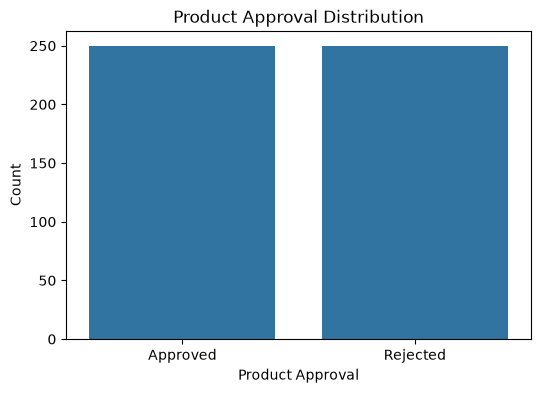

In [119]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["product_approval"])
plt.title("Product Approval Distribution")
plt.xlabel("Product Approval")
plt.ylabel("Count")
plt.show()

In [120]:
X = df.drop("product_approval", axis=1)
y = df["product_approval"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 10)
y shape: (500,)


In [121]:
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['product_type', 'packaging_type']


In [122]:
X = pd.get_dummies(X,columns=categorical_columns,drop_first=True)
X.head()

,shelf_life_days,storage_temperature_C,humidity_level_percent,moisture_content,preservative_level,pH_level,inspection_score_0_100,customer_rating_1_5,product_type_Canned Food,product_type_Dairy,product_type_Frozen Food,product_type_Juice,product_type_Ready-to-Eat,product_type_Snacks,packaging_type_Metal,packaging_type_Paper,packaging_type_Plastic,packaging_type_Tetra Pack,packaging_type_Vacuum Pack
0,345,3.8,44.6,30.1,2.76,6.16,83,4,False,False,True,False,False,False,False,True,False,False,False
1,264,1.2,50.5,19.3,1.99,6.48,83,5,True,False,False,False,False,False,False,False,False,False,True
2,125,0.7,40.9,30.0,5.48,6.51,95,3,False,False,False,False,False,True,True,False,False,False,False
3,189,0.9,63.3,19.5,4.76,5.21,97,5,False,True,False,False,False,False,False,False,True,False,False
4,44,0.5,67.4,7.3,4.03,5.15,97,5,False,False,False,False,False,True,False,True,False,False,False


In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [127]:
models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
models.items()


dict_items([('Logistic Regression', LogisticRegression(max_iter=1000)), ('Naive Bayes', GaussianNB()), ('Decision Tree', DecisionTreeClassifier(random_state=42)), ('Random Forest', RandomForestClassifier(random_state=42))])

In [131]:
results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results[name] = [acc, pre, rec, f1]

    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1-Score:", f1)

results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-Score"]
).T

results_df

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,1.0,1.0,1.0,1.0
Naive Bayes,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0


In [132]:
best_model_name = results_df['Recall'].idxmax()
print("Best model based on Recall:", best_model_name)
best_model = models[best_model_name]
if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)
    
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

Best model based on Recall: Logistic Regression
